In [1]:
from IPython.display import IFrame, display_html
from graphviz import Source
from sympy import *
from control.matlab import *

# Taller en sistemas continuos

# Parte 1: Introducción al control

Control también está estrechamente relacionado con la informática, ya que prácticamente todos los algoritmos de control sistemas de ingeniería se implementan en software. Sin embargo, los algoritmos y el software de control pueden ser muy diferentes de los programas informáticos tradicionales debido al papel central de la dinámica del sistema y a la tiempo real de la implementación.

## ¿Qué es la realimentación?

> El término retroalimentación se utiliza para referirse a una situación en la que dos (o más) sistemas dinámicos están conectados entre sí de tal manera que cada sistema influye en el otro y su dinámica está, por tanto, fuertemente acoplada. La simple rea es difícil porque el primer sistema influye en el segundo y el segundo influye en el primero. influye en el segundo y el segundo influye en el primero. circular. Esto dificulta el razonamiento basado en la causa y el efecto, y es necesario analizar el sistema en su conjunto. necesario analizar el sistema en su conjunto. Una consecuencia de ello es que el comportamiento de un sistema de retroalimentación suele ser contraintuitivo y, por tanto necesario recurrir a métodos formales para comprenderlos. -- Murray ([enlace](http://www.cds.caltech.edu/~murray/books/AM05/pdf/fbs-intro_07Aug2019.pdf))

## Ventajas de la realimentación

### 1. Robustes ante la incertidumbre

Analizando la diferencia entre el valor medido y el valor deseado, podemos tomar acciones correctivas. 
Cuando el sistema sufre cambios repentinos que afectan la señal regulada, sentimos el cambio y tratamos de forzar el sistema para que regrese a valor de operación deseado. 

## Ejemplo de control de velocidad de un vehículo

- ¿Qué pasa si el vehículo está por debajo de la velocidad deseada? 
- ¿Qué pasa si el vehículo tiene más pasajeros? 

## Ventajas de la realimentación

### 2. Modificación de la dinámica del sistema

A traves de la realimentación podemos alterar el comportamiento del sistema para que cumpla ciertos requerimientos de una aplicación: 

- Sistemas lentos que sean más reactivos
- Sistemas que derivan de su punto de operación sean más precisos
- Sistemas inestables que sean estables

## Ejemplo de la importancia del control 
### En los inicios de la aviación

> The difficulties which obstruct the pathway to success in flying-machine construction are of three general classes: (1) Those which relate to the construction of the sustaining wings; (2) those which relate to the generation and application of the power required to drive the machine through the air; (3) those relating to <u>the balancing and steering of the machine after it is actually in flight.</u> -- Wilbur WRIGHT ([Some Aeronautical Experiments](https://invention.psychology.msstate.edu/i/Wrights/library/Aeronautical.html), 1901)$^1$
    
    
![](https://upload.wikimedia.org/wikipedia/commons/d/d6/Curtiss_%27Flying_Fish%27_%28Flying_Boat_Nr.2%29.jpg)

## Ejemplo de la importancia del control 
### El piloto automático$^{1,2}$

[![](curt-sperry.jpg)](http://aerofiles.com/_sk.html)

1. [Feedback Systems: Introduction](http://www.cds.caltech.edu/~murray/books/AM05/pdf/fbs-intro_07Aug2019.pdf)
2. [Feedback Systems: Book](https://fbswiki.org)

### Airbus A380 en condiciones extremas

In [2]:
display(IFrame(
    "https://www.youtube-nocookie.com/embed/NHw1QDn5mxM?controls=0",
    width="100%",
    height="450px"))

## Dinámica del sistema

La dinámica de los sistemas en observación viene definida por la relación entre las **entradas** y las **salidas**. Una vez que un sistema continuo recibe una **entrada**, produce una **salida** continua que cambia con el tiempo. Esta **salida** pasa por dos estados diferentes: transitorio y estacionario . Durante el estado transitorio, la respuesta de **salida** varía a lo largo del tiempo hasta que alcanza el estado estacionario, lo que significa que la salida tiene un valor constante a lo largo del tiempo. Observe que el estado estacionario sólo se aplica a los sistemas estables y continuos.

<img src="https://upload.wikimedia.org/wikipedia/commons/9/9a/SR-SDoF.gif" width="450px"/>

In [3]:
%%file ft.gv
// Diagrama de bloques de la función de transferencia
digraph {
    rankdir=LR
    B [shape=rectangle,label="Funcion de Transferencia", style=filled, fillcolor=lightgray]
    node[shape="none"]   
    E [label="entrada"]
    U [label="salida"]
    E -> B -> U
}

Overwriting ft.gv


In [4]:
# Instalar https://www.graphviz.org/download/ y agregar al %PATH%

sourcefile = 'ft.gv'
gv = open(sourcefile)
dot = Source(gv.read(),format="svg",filename = sourcefile)
dot.render(sourcefile,view=False);

## Modelizado de la dinámica de un sistema

La dinámica del sistema se modela mediante un sistema de ecuaciones diferenciales simultáneas. Para resolverlas fácilmente, se puede utilizar la transformada de _Laplace_ que convierte la solución de estas ecuaciones diferenciales en más simples ecuaciones algebraicas lineales. Estas ecuaciones de _Laplace_ pueden representar la relación causal entre la **entrada** y la **salida**, que se llamará **"Función de Transferencia"** y se representada gráficamente con un diagrama de bloques.

![](ft.gv.svg)

y representada matematicamente:

$$G(s)=\frac{\text{salida}}{\text{entrada}} = \frac{Y(s)}{U(s)}$$

In [5]:
%%file mass-spring.gv
// Diagrama de bloques de la función de transferencia
digraph {
    rankdir=LR
    B [shape=rectangle,label="Masa-Resorte", style=filled, fillcolor=lightgray]
    node[shape="none"]   
    E [label="fuerza"]
    U [label="desplazamiento"]
    E -> B -> U
}

Overwriting mass-spring.gv


In [6]:
sourcefile = 'mass-spring.gv'
gv = open(sourcefile)
dot = Source(gv.read(),format="svg",filename = sourcefile)
dot.render(sourcefile,view=False);

## Modelizado de un sistema masa resorte

![](mass-spring.gv.svg)

Para el modelizado realizamos diagrama de cuerpo libre y aplicado la segunda ley del movimiento de _Newton_

$$\Sigma f_x = m \frac{d^2x(t)}{dt^2}$$

$$f(t) - k\,x(t) = m \frac{d^2x(t)}{dt^2}$$

## Modelizado de un sistema masa resorte

$$f(t) - k\,x(t) = m \frac{d^2x(t)}{dt^2}$$

Teniendo la ecuación diferencial aplicamos tranformada de _Laplace_

$$F(s) - k\, X(s) = m \left(s^2 X(s) - s\,x(0) - \dot{x}(0)\right)$$
$$F(s) = m s^2 X(s) +  k\, X(s)$$

De aquí despejamos la función de transferencia:

$$\frac{X(s)}{F(s)} = \frac{1}{ms^2+k}$$

In [7]:
%%file mass-damp-spring.gv
// Diagrama de bloques de la función de transferencia
digraph {
    rankdir=LR
    B [shape=rectangle,label="Masa-Resorte-Amortiguador", style=filled, fillcolor=lightgray]
    node[shape="none"]   
    E [label="fuerza"]
    U [label="desplazamiento"]
    E -> B -> U
}

Overwriting mass-damp-spring.gv


In [8]:
sourcefile = 'mass-damp-spring.gv'
gv = open(sourcefile)
dot = Source(gv.read(),format="svg",filename = sourcefile)
dot.render(sourcefile,view=False);

## Ejercicio 

Encontrar la función de transferencia de un sistema masa-resorte-amortiguador

![](mass-damp-spring.gv.svg)

cuya ecuación diferencial es:

$$f(t) - k\,x(t) - b \frac{d x(t)}{dt}= m \frac{d^2x(t)}{dt^2}$$

**Función de transferencia**

$$\frac{X(s)}{F(s)} = \frac{1}{ms^2+bs+k}$$

## Ejercicios de identificación

Pensemos en la caché de un servidor web. Si se realiza una petición al sistema, éste busca primero en la caché el elemento solicitado y lo devuelve al usuario si lo encuentra. Sólo si no se encuentra el elemento, éste se recuperará del almacenamiento persistente. La caché puede contener un número finito de elementos, por lo que cuando un elemento se obtiene del almacenamiento persistente, sustituye al elemento más antiguo actualmente en la caché. 

**Identifiquemos las entradas y salidas**

## Ejercicios de identificación

En un sistema informático se requiere una refrigeración activa refrigeración activa mediante ventiladores para temperaturas de funcionamiento aceptables.

**Identifiquemos las entradas y salidas del sistema** 

# Información [EXTRA](extra.pdf)

In [9]:
from IPython.display import IFrame, display_html

try: 
  from control.matlab import *
except:
  !pip install control
  from control.matlab import *

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4,3)

import numpy as np
import sympy as sp
import pandas as pd
import scipy.optimize as op 

sp.init_printing()

import warnings
warnings.filterwarnings(action='ignore')

# Parte 2: Modelizado Experimental

**Tenemos un sistema de iluminación en lazo cerrado que se dedica a una tarea especifica sin cambiar su referencia o _set-point_** (Generación 0).

Vamos a encontrar el modelo matemático del siguiente sistema usando datos experimentales. 

<img src="planta.jpeg" width="400px">

La planta es un sistema de iluminación con un LED de potencia (actuador) y un LDR (sensor). Este sistema es controlado a través de un Arduino Mega (actualmente Arduino Mega, en la foto Arduino Uno).

## Toma de datos

Para la toma de datos usaremos el código en lazo abierto para Arduino. Y seguiremos los pasos mostrado a continuación.

- Descargamos el código.
- Subimos el código al Arduino.
- Abrimos el monitor serial.
- Copiamos los datos de un ciclo completo de apagado y prendido.
- Pegamos en un archivo llamado `datos.csv` con nombre de las columnas `t,u,y`.
- Finalmente, importamos los datos en el Colaboratory o Jupyter Notebook con pandas. 

💾 [Código arduino para el lazo abierto](/arduino/continuos/lazo_abierto/lazo_abierto.ino)

A continuación se muestran algunos datos.

In [11]:
datos = pd.read_csv("datos.csv")
datos

,t,u,y
0,60968004,0,455
1,60972004,0,454
2,60976004,0,455
3,60980004,0,455
4,60984004,0,455
...,...,...,...
253,61980004,255,653
254,61984004,255,653
255,61988004,255,653
256,61992004,255,653


## Modelizado experimental

Despues de importar los datos, los extraemos en vectores y graficamos.

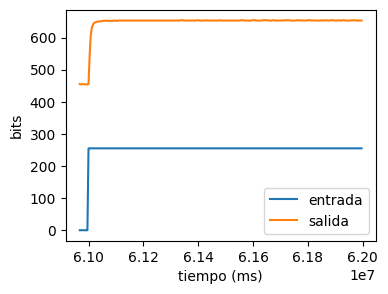

In [12]:
traw = np.array(datos["t"].tolist())
uraw = np.array(datos["u"].tolist())
yraw = np.array(datos["y"].tolist())

plt.plot(traw,uraw,traw,yraw);
plt.xlabel("tiempo (ms)");
plt.ylabel("bits");
plt.legend(["entrada","salida"]);

Para la construcción del modelo necesitamos tratar los datos, cambiaremos las unidades del tiempo que esta en microsegundos. 

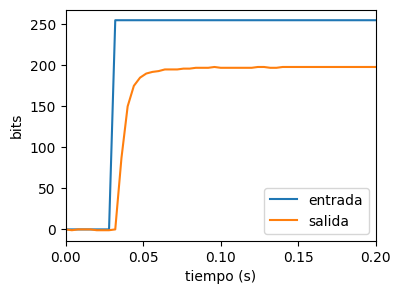

In [13]:
t = (traw - traw[0])/1e6
u = (uraw - uraw[0])
y = (yraw - yraw[0])

plt.plot(t,u,t,y);
plt.xlim((0,0.2));
plt.xlabel("tiempo (s)");
plt.ylabel("bits");
plt.legend(["entrada","salida"]);

Por la respuesta del sistema podemos suponer que es un sistema de primer orden con retardo. La función de transferencia para dicho sistema está dada por la expresión: 

$$G(s) = \frac{\gamma}{\tau\,s+1}e^{-\theta\,s}$$

Podemos suponer los valores de los parámetros y modificarlos hasta que las gráficas se parezcan. 

In [14]:
s = tf("s")

gamma = y[-1]/u[-1]
tau   = 0.0044376
theta = 0.004

num,den = pade(theta,n=5)
retardo = tf(num,den)

G = gamma/(tau*s+1)

print("------------------------")
print("Función de transferencia\n")
display(G)
GR = G*retardo

------------------------
Función de transferencia



TransferFunction(array([0.77647059]), array([0.0044376, 1.       ]))

La anterior expresión toma valores encontrados al tanteo. 

Aproximación del modelo

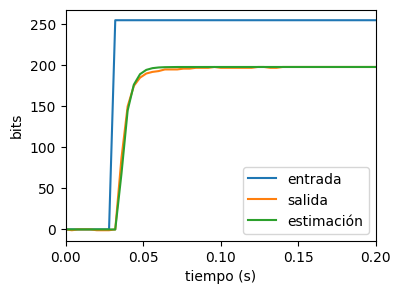

In [15]:
T = np.linspace(t[0],t[-1],num=len(t))
ysim,tsim,_ = lsim(GR,U=u,T=T)

plt.plot(t,u,t,y,tsim,ysim);
plt.xlim((0,0.2));
plt.xlabel("tiempo (s)");
plt.ylabel("bits");
plt.legend(["entrada","salida","estimación"]);

Se ve que siguen habiendo diferencias entre el modelo y los datos. Aquí, podemos contruir un algoritmo de optimización que minimize el error cuadratico entre las dos respuestas (modelo y datos). 

Estos son los resultados:

In [16]:
def model(x):
  gamma, tau, theta = x
  theta = max(abs(theta),0.001)
  G = gamma/(tau*s+1)
  num,den = pade(theta,n=5)
  retardo = tf(num,den)
  GR = G*retardo
  ysim,tsim,_ = lsim(GR,U=u,T=T)
  return np.sum((y-ysim)**2)

result = op.minimize(model,[0.77,0.005,0.004])
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 171.0746620929305
        x: [ 7.766e-01  5.023e-03  3.013e-03]
      nit: 11
      jac: [ 2.429e-01  1.100e+01  1.519e+01]
 hess_inv: [[ 3.090e-08  2.338e-10  2.370e-10]
            [ 2.338e-10  4.019e-11  4.061e-11]
            [ 2.370e-10  4.061e-11  7.413e-11]]
     nfev: 159
     njev: 35

En el anterior resultado encontramos los valores optimizados para los parametros del modelo $\gamma$, $\tau$ y $\theta$. Con estos parámetros podemos verificar la respuesta nuevamente.

In [17]:
gamma, tau, theta = result.x
num,den = pade(theta,n=5)
retardo = tf(num,den)

G = gamma/(tau*s+1)
GR = G*retardo

print("Retardo:",theta)

Retardo: 0.003013355936680472


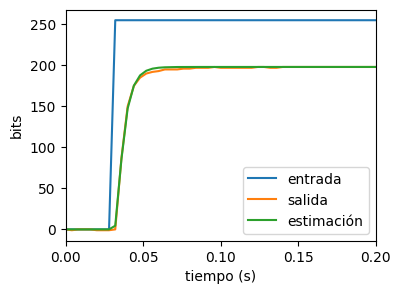

In [18]:
T = np.linspace(t[0],t[-1],num=len(t))
ysim,tsim,_ = lsim(GR,U=u,T=T)

plt.plot(t,u,t,y,tsim,ysim);
plt.xlim((0,0.2));
plt.xlabel("tiempo (s)");
plt.ylabel("bits");
plt.legend(["entrada","salida","estimación"]);

## Diseño de un controlador (PID)

Para el diseño del controlador podemos usar un controlador PID o diseñar un controlador usando la representación en espacio de estados. Primero usaremos un PID, en este caso usamos un controlador PI, y los parámetros fueron ajustados manualmente. 

💾 [Código arduino para el lazo cerrado](/arduino/continuos/lazo_cerrado/lazo_cerrado.ino)

Controlador PI :


TransferFunction(array([2.5, 3. ]), array([1., 0.]))

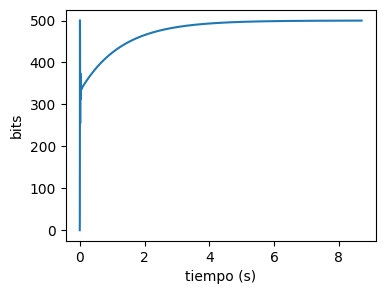

In [19]:
Kp = 2.5
Ki = 3
Kd = 0.00
K  = Kp + Ki/s + Kd*s

print("Controlador PI :")
display(K)
CPID = feedback(K*GR,1)
yy,tt = step(500*CPID)
plt.plot(tt,yy); 
plt.xlabel("tiempo (s)");
plt.ylabel("bits");

In [20]:
print("Información de la respuesta a un escalón:\n")

stepinfo(500*CPID)

Información de la respuesta a un escalón:



{'RiseTime': 0.0034816640690269536,
 'SettlingTime': 3.566964838718114,
 'SettlingMin': 254.835424623772,
 'SettlingMax': 500.74298048728696,
 'Overshoot': 0.14859609745739136,
 'Undershoot': 0,
 'Peak': 500.74298048728696,
 'PeakTime': 0.006963328138053907,
 'SteadyStateValue': 500.0}

Se puede intentar optimizar el resultado utilizando una heuristica: 

In [21]:
def controller(x):
  Kp, Ki, Kd = x
  Kp = max(0,Kp)
  Ki = max(0,Ki)
  Kd = max(0,Kd)
  K  = Kp + Ki/s + Kd*s
  CPID = feedback(K*GR,1)
  info = stepinfo(CPID)
  return (info['Overshoot']+0.1)*(info['SettlingTime'])

result = op.minimize(controller,[2.5,3,0])
result

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.3559594000412233
        x: [ 2.490e+00  2.997e+00 -6.808e-03]
      nit: 2
      jac: [ 9.464e-02  2.333e+04  0.000e+00]
 hess_inv: [[ 2.276e-01  3.415e-01 -4.008e-01]
            [ 3.415e-01  5.122e-01 -6.012e-01]
            [-4.008e-01 -6.012e-01  7.055e-01]]
     nfev: 151
     njev: 35

Con este resultado:

Controlador PI :


TransferFunction(array([2.49013324, 2.99689027]), array([1, 0]))

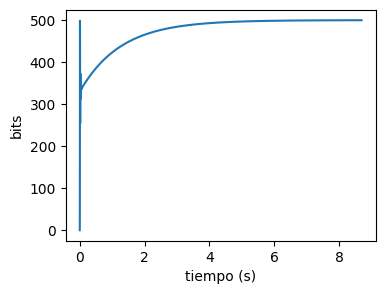

In [22]:
Kp, Ki, Kd = result.x
K  = Kp + Ki/s

print("Controlador PI :")
display(K)
CPID = feedback(K*GR,1)
yy,tt = step(500*CPID)
plt.plot(tt,yy); 
plt.xlabel("tiempo (s)");
plt.ylabel("bits");